# Семинар 1. Регуляризация как контроль сложности модели

Этот ноутбук рассказ о том, **почему нейронная сеть начинает переобучаться**
и **какими практическими инструментами мы можем управлять этим процессом**.

Мы начнём с наблюдения *learning curves* у базовой модели,
затем шаг за шагом добавим регуляризацию и посмотрим,
как меняется динамика обучения и качество на валидации и тесте.

> **Версия для преподавателя.** Все графики — эталонные ориентиры; конкретные числа могут отличаться, важна форма кривых.

## Идея семинара

Переобучение — это не «ошибка оптимизации», а следствие слишком большой
гибкости модели относительно объёма и шума данных.

Регуляризация ограничивает пространство допустимых решений.
Каждый следующий приём в этом семинаре **отвечает на проблему,
обнаруженную в предыдущей задаче**.

In [ ]:
# Общие импорты и настройки
import random, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
from typing import List, Tuple

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

base_tf = transforms.ToTensor()
full = datasets.FashionMNIST(root="./data", train=True, download=True, transform=base_tf)
test_ds = datasets.FashionMNIST(root="./data", train=False, download=True, transform=base_tf)

val_size = 10_000
train_size = len(full) - val_size
train_ds, val_ds = random_split(full, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2)

len(train_ds), len(val_ds), len(test_ds)

100%|██████████| 26.4M/26.4M [00:05<00:00, 4.56MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 746kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 7.98MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 29.7MB/s]


(50000, 10000, 10000)

In [ ]:
@dataclass
class History:
    train_loss: List[float]
    val_loss: List[float]
    train_acc: List[float]
    val_acc: List[float]

def accuracy_from_logits(logits, y):
    return (logits.argmax(1) == y).float().mean().item()

@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    L, A, N = 0.0, 0.0, 0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        logits = model(x)
        loss = loss_fn(logits, y)
        b = x.size(0)
        L += loss.item()*b
        A += accuracy_from_logits(logits, y)*b
        N += b
    return L/N, A/N

def train_one_epoch(model, loader, loss_fn, optimizer):
    model.train()
    L, A, N = 0.0, 0.0, 0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        b = x.size(0)
        L += loss.item()*b
        A += accuracy_from_logits(logits, y)*b
        N += b
    return L/N, A/N

def fit(model, train_loader, val_loader, loss_fn, optimizer, epochs=10, early_stopping=False, patience=3):
    hist = History([], [], [], [])
    best_val = float("inf")
    best_state = None
    bad = 0
    for _ in range(epochs):
        tl, ta = train_one_epoch(model, train_loader, loss_fn, optimizer)
        vl, va = evaluate(model, val_loader, loss_fn)
        hist.train_loss.append(tl)
        hist.val_loss.append(vl)
        hist.train_acc.append(ta)
        hist.val_acc.append(va)
        if early_stopping:
            if vl < best_val - 1e-6:
                best_val = vl
                best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
                bad = 0
            else:
                bad += 1
                if bad >= patience:
                    break
    if early_stopping and best_state is not None:
        model.load_state_dict(best_state)
    return hist

In [ ]:
class MLP(nn.Module):
    def __init__(self, dropout_p=0.0):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(dropout_p)
    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        return self.fc3(x)

def weight_norms(model):
    with torch.no_grad():
        return {n: float(p.norm()) for n,p in model.named_parameters() if p.ndim>=2}

## Шаг 1. Базовая модель как точка отсчёта

Прежде чем лечить переобучение, нужно **увидеть его симптомы**.
Мы начинаем с модели без регуляризации и анализируем её кривые обучения.

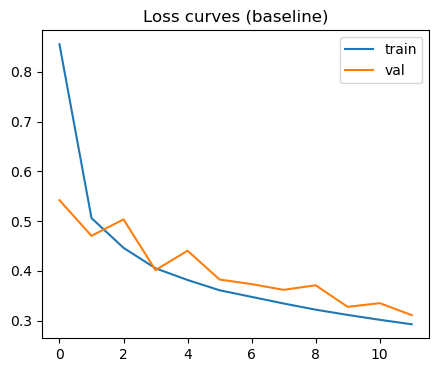

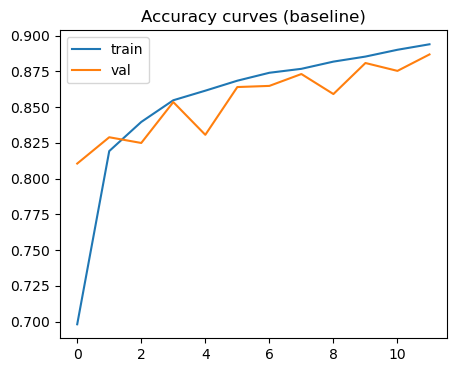

0.8746

In [ ]:
import matplotlib.pyplot as plt

model = MLP(dropout_p=0.0).to(device)
loss_fn = nn.CrossEntropyLoss()
opt = torch.optim.SGD(model.parameters(), lr=0.1)

hist = fit(model, train_loader, val_loader, loss_fn, opt, epochs=12)

plt.figure(figsize=(5,4))
plt.plot(hist.train_loss, label="train")
plt.plot(hist.val_loss, label="val")
plt.legend(); plt.title("Loss curves (baseline)"); plt.show()

plt.figure(figsize=(5,4))
plt.plot(hist.train_acc, label="train")
plt.plot(hist.val_acc, label="val")
plt.legend(); plt.title("Accuracy curves (baseline)"); plt.show()

test_loss, test_acc = evaluate(model, test_loader, loss_fn)
test_acc

**Наблюдение.**  
Если разрыв между train и val растёт — модель начинает подгонять шум.
Это сигнал к введению регуляризации.

## Шаг 2. Early stopping как ограничение по времени обучения

Один из самых простых способов борьбы с переобучением —
**остановить обучение в момент наилучшего обобщения**.

Early stopping фактически ограничивает эффективную сложность модели,
не меняя её архитектуру.

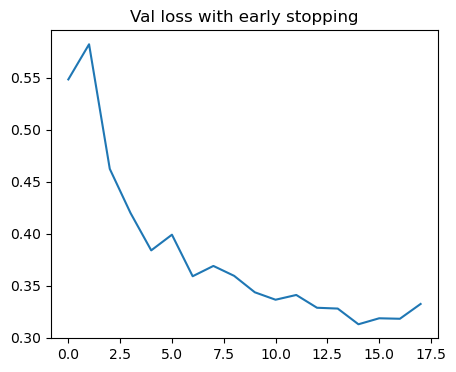

(18, 0.8758)

In [ ]:
model_es = MLP(dropout_p=0.0).to(device)
opt_es = torch.optim.SGD(model_es.parameters(), lr=0.1)

hist_es = fit(model_es, train_loader, val_loader, loss_fn, opt_es,
              epochs=40, early_stopping=True, patience=3)

plt.figure(figsize=(5,4))
plt.plot(hist_es.val_loss); plt.title("Val loss with early stopping"); plt.show()

len(hist_es.val_loss), evaluate(model_es, test_loader, loss_fn)[1]

Early stopping особенно полезен, когда:
- модель большая,
- данные шумные,
- вычислительный бюджет ограничен.

## Шаг 3. L2-регуляризация и weight decay

Теперь ограничим модель **явно**, добавив штраф за большие веса.
Это заставляет оптимизацию предпочитать более «гладкие» решения.

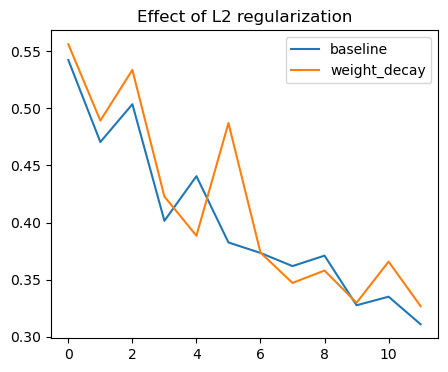

({'fc1.weight': 15.661869049072266,
  'fc2.weight': 11.339093208312988,
  'fc3.weight': 6.904562473297119},
 {'fc1.weight': 15.067181587219238,
  'fc2.weight': 10.926246643066406,
  'fc3.weight': 6.757454872131348})

In [ ]:
model_wd = MLP(dropout_p=0.0).to(device)
opt_wd = torch.optim.SGD(model_wd.parameters(), lr=0.1, weight_decay=1e-4)

hist_wd = fit(model_wd, train_loader, val_loader, loss_fn, opt_wd, epochs=12)

plt.figure(figsize=(5,4))
plt.plot(hist.val_loss, label="baseline")
plt.plot(hist_wd.val_loss, label="weight_decay")
plt.legend(); plt.title("Effect of L2 regularization"); plt.show()

weight_norms(model), weight_norms(model_wd)

**Интерпретация.**  
Weight decay уменьшает нормы весов и снижает variance модели,
часто улучшая поведение на валидации.

## Шаг 4. Комбинация методов

На практике методы регуляризации **комбинируются**.
Проверим, даёт ли сочетание early stopping и weight decay дополнительный выигрыш.

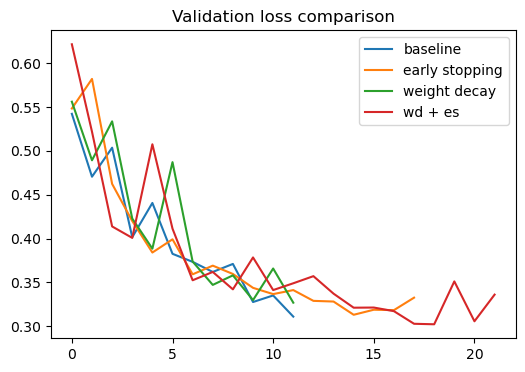

0.8788

In [ ]:
model_combo = MLP(dropout_p=0.0).to(device)
opt_combo = torch.optim.SGD(model_combo.parameters(), lr=0.1, weight_decay=1e-4)

hist_combo = fit(model_combo, train_loader, val_loader, loss_fn, opt_combo,
                 epochs=40, early_stopping=True, patience=3)

plt.figure(figsize=(6,4))
plt.plot(hist.val_loss, label="baseline")
plt.plot(hist_es.val_loss, label="early stopping")
plt.plot(hist_wd.val_loss, label="weight decay")
plt.plot(hist_combo.val_loss, label="wd + es")
plt.legend(); plt.title("Validation loss comparison"); plt.show()

evaluate(model_combo, test_loader, loss_fn)[1]

## Выводы семинара 1

1. Переобучение диагностируется по кривым обучения.
2. Early stopping ограничивает время обучения.
3. L2/weight decay ограничивает пространство параметров.
4. Комбинации методов часто дают наилучший результат.

